# Benefits & Claims Fraud Detection: Production-Grade Compliance Analytics for Government

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Fraud detection in government benefits and claims processing — building ethical, accountable ML for social services

---

This notebook builds a production-oriented fraud detection system for claims processing. While using an insurance claims dataset as a proxy, the entire analysis is framed around Australian government welfare and benefits compliance — the kind of system that supports Services Australia, NDIA, and DVA claims integrity operations.

**Critical context — lessons from Robodebt:**
The Robodebt Royal Commission (2023) demonstrated what happens when automated compliance systems lack proper safeguards. Key findings:
- Automated decisions must have a **clear legal basis** (Social Security Act 1991)
- **Income averaging** without individual assessment was unlawful
- Systems must provide **natural justice** — right to respond before adverse action
- **Human oversight** is mandatory for decisions affecting entitlements
- Vulnerable populations require additional protections

**This notebook explicitly addresses these concerns by:**
- Building a *decision-support* tool, not an automated decision-maker
- Requiring human review before any adverse compliance action
- Including fairness auditing across demographic groups
- Designing for transparency and explainability
- Framing all analysis within the Social Security Act and APS Code of Conduct

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Claims Risk Profile Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability & Fairness Safeguards
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss,
    classification_report
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

import os
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.base import clone

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

COLOR_LEGIT = '#2ecc71'
COLOR_FRAUD = '#e74c3c'
COLOR_PALETTE = [COLOR_LEGIT, COLOR_FRAUD]

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Data Loading & Initial Assessment

The Auto Insurance Claims dataset serves as a proxy for government benefits claims. The feature structure maps to welfare compliance contexts:

| Insurance Feature | Government Benefits Equivalent |
|-------------------|-------------------------------|
| Policy holder demographics | Recipient demographics (age, location) |
| Claim amount | Benefit payment amount |
| Incident details | Claim circumstances / change of circumstances |
| Policy type & premium | Benefit type & entitlement level |
| Capital gains/losses | Income & assets assessment |
| Witnesses, police report | Supporting documentation, third-party verification |

The fraud detection objective is identical: identify potentially non-genuine claims for human review, while ensuring legitimate claimants receive timely payments.

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','

df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Separator: '{sep}'")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded: /kaggle/input/datasets/buntyshah/auto-insurance-claims-data/insurance_claims.csv
Shape: 1,000 rows × 40 columns
Separator: ','
Memory: 1.3 MB


In [3]:
# Schema overview
print("=" * 70)
print("SCHEMA OVERVIEW")
print("=" * 70)
for col in df.columns:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
    print(f"  {col:<35} {str(dtype):<10} unique={nunique:<8} nulls={nulls:<5} ex={sample}")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
df.head()

SCHEMA OVERVIEW
  months_as_customer                  int64      unique=391      nulls=0     ex=328
  age                                 int64      unique=46       nulls=0     ex=48
  policy_number                       int64      unique=1000     nulls=0     ex=521585
  policy_bind_date                    object     unique=951      nulls=0     ex=2014-10-17
  policy_state                        object     unique=3        nulls=0     ex=OH
  policy_csl                          object     unique=3        nulls=0     ex=250/500
  policy_deductable                   int64      unique=3        nulls=0     ex=1000
  policy_annual_premium               float64    unique=991      nulls=0     ex=1406.91
  umbrella_limit                      int64      unique=11       nulls=0     ex=0
  insured_zip                         int64      unique=995      nulls=0     ex=466132
  insured_sex                         object     unique=2        nulls=0     ex=MALE
  insured_education_level             obj

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [4]:
# Handle '?' as missing values (common in this dataset)
df.replace('?', np.nan, inplace=True)

# Identify target column
target_col = None
for col in df.columns:
    if 'fraud' in col.lower():
        target_col = col
        break

if target_col is None:
    # Fallback: look for binary columns with Yes/No or Y/N
    for col in df.select_dtypes(include=['object']).columns:
        vals = set(df[col].dropna().str.upper().unique())
        if vals <= {'Y', 'N'} or vals <= {'YES', 'NO'}:
            target_col = col
            break

print(f"Target column: {target_col}")
print(f"Values: {df[target_col].value_counts().to_dict()}")

# Determine classes programmatically
class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_count = class_counts[majority_class]
minority_count = class_counts[minority_class]
fraud_pct = minority_count / len(df) * 100

print(f"\n{'='*60}")
print("CLASS DISTRIBUTION")
print(f"{'='*60}")
print(f"Legitimate ({majority_class}): {majority_count:,} ({majority_count/len(df)*100:.1f}%)")
print(f"Fraud      ({minority_class}): {minority_count:,} ({fraud_pct:.1f}%)")
print(f"Ratio: 1:{majority_count/minority_count:.1f}")

print(f"\nIn welfare context: ~{fraud_pct:.0f}% of claims flagged for investigation.")
print(f"Services Australia estimates 1-3% of welfare payments involve non-compliance.")
print(f"This dataset has a higher fraud rate, which is typical of curated ML datasets.")

Target column: fraud_reported
Values: {'N': 753, 'Y': 247}

CLASS DISTRIBUTION
Legitimate (N): 753 (75.3%)
Fraud      (Y): 247 (24.7%)
Ratio: 1:3.0

In welfare context: ~25% of claims flagged for investigation.
Services Australia estimates 1-3% of welfare payments involve non-compliance.
This dataset has a higher fraud rate, which is typical of curated ML datasets.


---
## 2. Exploratory Data Analysis

Claims fraud EDA focuses on identifying patterns in claimant behaviour, claim characteristics, and contextual signals that distinguish genuine from potentially fraudulent claims. In government welfare, this maps to compliance analytics — identifying patterns in payment data, change-of-circumstances reporting, and income declarations.

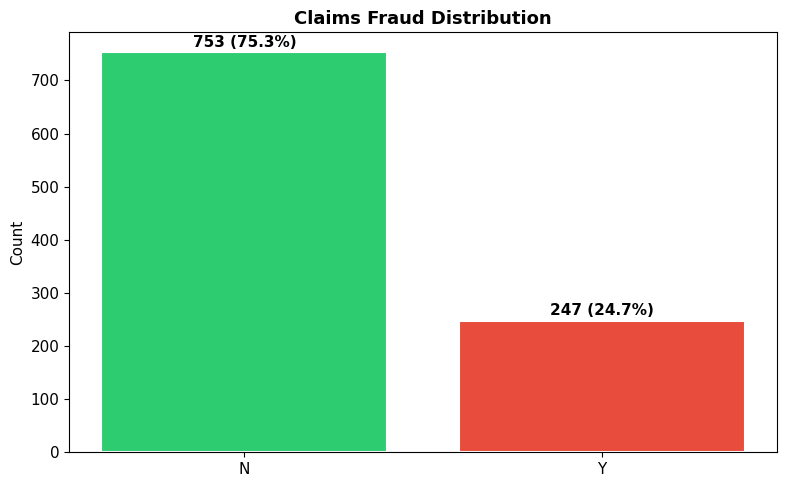

In [5]:
# 2.1 Class distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLOR_LEGIT if str(c).upper() in ['N', 'NO', '0', majority_class] else COLOR_FRAUD for c in class_counts.index]
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Claims Fraud Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{count:,} ({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

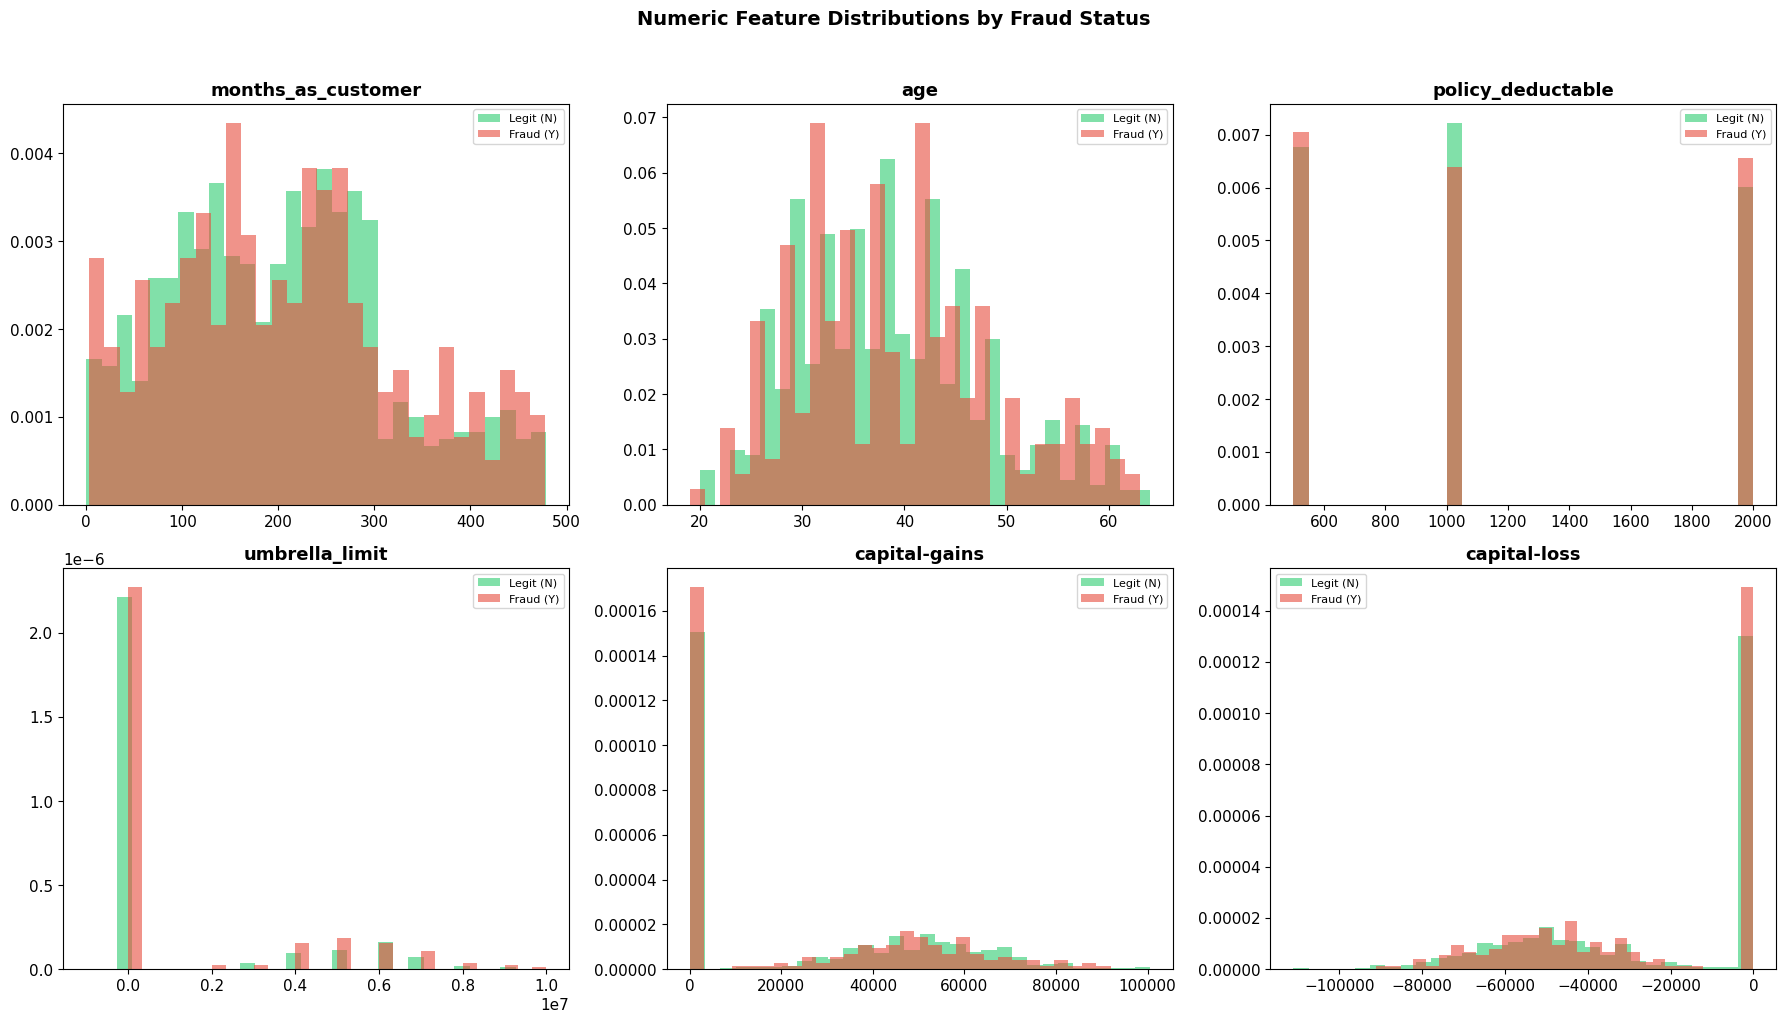

In [6]:
# 2.2 Numeric features — distributions by fraud status
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove obvious IDs
id_like = [c for c in num_cols if df[c].nunique() > len(df) * 0.9]
num_cols = [c for c in num_cols if c not in id_like]

n_plot = min(len(num_cols), 6)
if n_plot > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes_flat = axes.flatten()
    
    for idx, col in enumerate(num_cols[:n_plot]):
        ax = axes_flat[idx]
        for cls in [majority_class, minority_class]:
            color = COLOR_LEGIT if cls == majority_class else COLOR_FRAUD
            label = f'Legit ({cls})' if cls == majority_class else f'Fraud ({cls})'
            subset = df[df[target_col] == cls][col].dropna()
            ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
    
    for idx in range(n_plot, 6):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle('Numeric Feature Distributions by Fraud Status', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

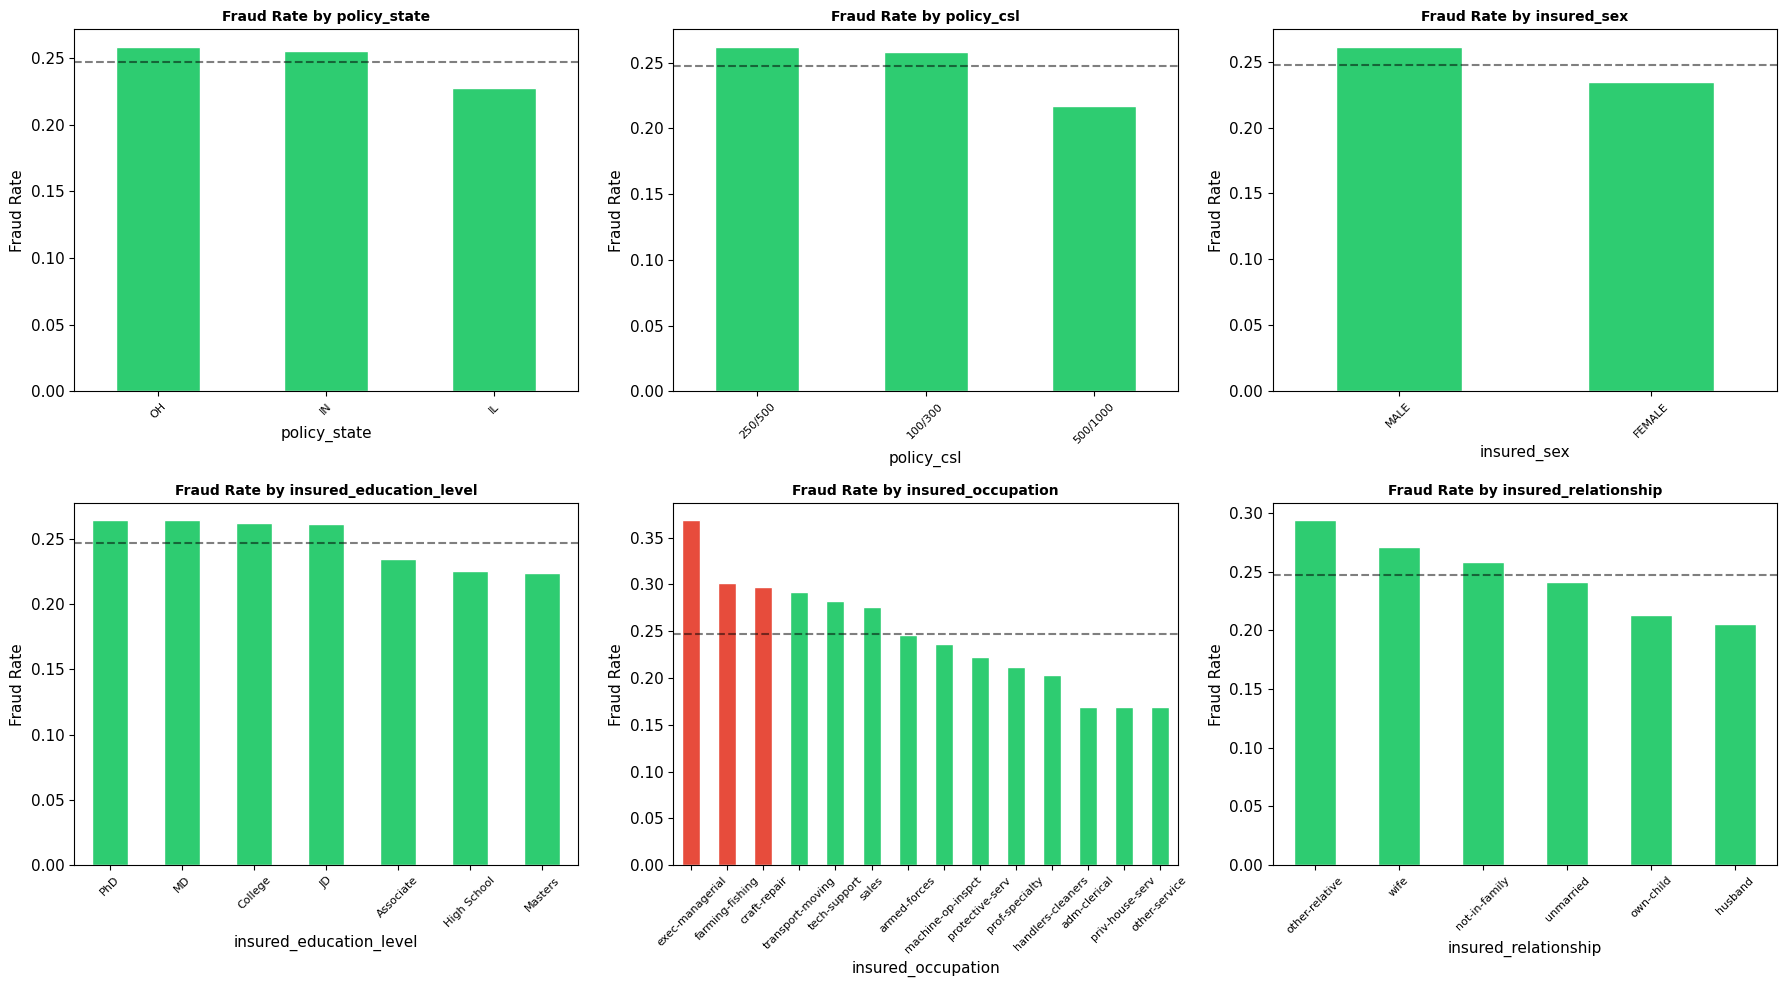

In [7]:
# 2.3 Categorical features — fraud rate by category
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and df[c].nunique() < 20]

n_cats = min(len(cat_cols), 6)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = np.array(axes).flatten()
    
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        fraud_rate = df.groupby(col)[target_col].apply(
            lambda x: (x == minority_class).mean()
        ).sort_values(ascending=False)
        
        colors = [COLOR_FRAUD if r > fraud_pct/100 * 1.2 else COLOR_LEGIT for r in fraud_rate.values]
        fraud_rate.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Fraud Rate by {col}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Fraud Rate')
        ax.axhline(y=fraud_pct/100, color='black', linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

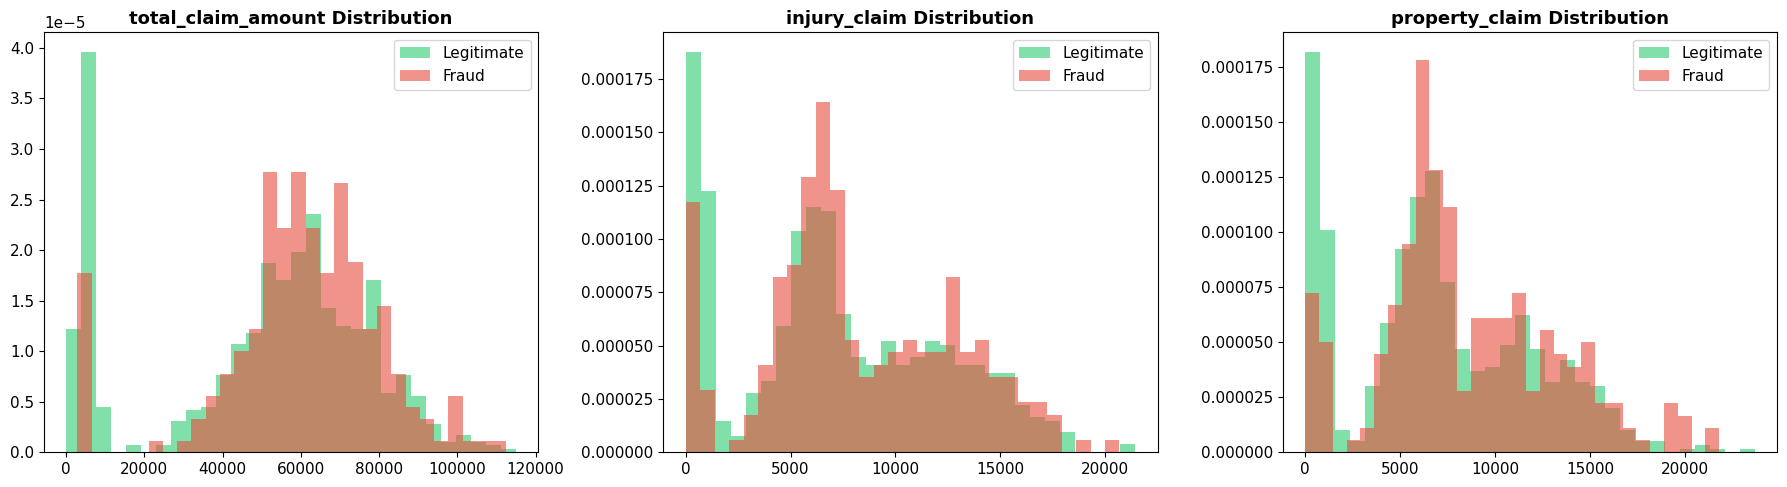


Claim amount comparison:
  total_claim_amount: Legit mean=$50,289 | Fraud mean=$60,302 | Diff=+19.9%
  injury_claim: Legit mean=$7,179 | Fraud mean=$8,208 | Diff=+14.3%
  property_claim: Legit mean=$7,019 | Fraud mean=$8,560 | Diff=+22.0%


In [8]:
# 2.4 Claim amount analysis
claim_cols = [c for c in df.columns if 'claim' in c.lower() and df[c].dtype in ['int64', 'float64']]
if not claim_cols:
    claim_cols = [c for c in num_cols if 'amount' in c.lower() or 'claim' in c.lower() or 'total' in c.lower()]

if claim_cols:
    fig, axes = plt.subplots(1, min(len(claim_cols), 3), figsize=(18, 5))
    if len(claim_cols) == 1:
        axes = [axes]
    elif len(claim_cols) > 3:
        claim_cols = claim_cols[:3]
    
    for idx, col in enumerate(claim_cols):
        ax = axes[idx]
        for cls, color, label in [(majority_class, COLOR_LEGIT, 'Legitimate'), 
                                   (minority_class, COLOR_FRAUD, 'Fraud')]:
            subset = df[df[target_col] == cls][col].dropna()
            ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\nClaim amount comparison:")
    for col in claim_cols:
        legit_mean = df[df[target_col] == majority_class][col].mean()
        fraud_mean = df[df[target_col] == minority_class][col].mean()
        print(f"  {col}: Legit mean=${legit_mean:,.0f} | Fraud mean=${fraud_mean:,.0f} "
              f"| Diff={((fraud_mean-legit_mean)/legit_mean*100):+.1f}%")

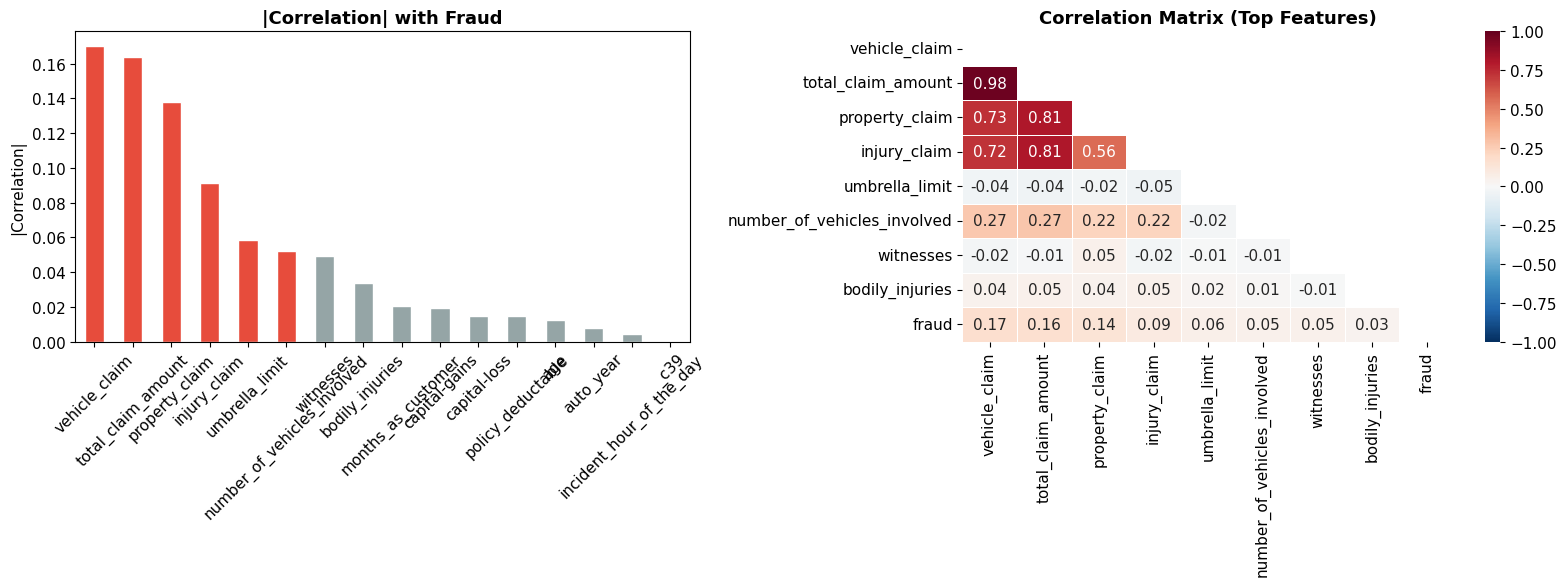

In [9]:
# 2.5 Correlation heatmap (numeric features)
if len(num_cols) > 1:
    target_binary = (df[target_col] == minority_class).astype(int)
    corr_data = df[num_cols].copy()
    corr_data['fraud'] = target_binary
    corr_matrix = corr_data.corr()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Correlation with fraud
    target_corr = corr_matrix['fraud'].drop('fraud').abs().sort_values(ascending=False)
    colors_c = [COLOR_FRAUD if c > 0.05 else '#95a5a6' for c in target_corr.values]
    target_corr.plot(kind='bar', ax=axes[0], color=colors_c, edgecolor='white')
    axes[0].set_title('|Correlation| with Fraud', fontweight='bold')
    axes[0].set_ylabel('|Correlation|')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Full heatmap (top correlated)
    top_corr_cols = target_corr.head(8).index.tolist() + ['fraud']
    mask = np.triu(np.ones_like(corr_data[top_corr_cols].corr(), dtype=bool))
    sns.heatmap(corr_data[top_corr_cols].corr(), mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, ax=axes[1], linewidths=0.5, vmin=-1, vmax=1)
    axes[1].set_title('Correlation Matrix (Top Features)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

---
## 3. Feature Engineering & Preprocessing

In welfare compliance, feature engineering draws on payment history, income data, and behavioural patterns. Here we engineer features that capture:
- **Claim magnitude** — total and component claim amounts
- **Demographic risk signals** — not for discrimination, but for resource allocation
- **Behavioural indicators** — patterns that differ between genuine and fraudulent claims
- **Policy/entitlement context** — duration, type, premium/payment level

In [10]:
# 3.1 Feature engineering
df_feat = df.copy()

# Drop high-cardinality ID-like columns
drop_initial = [c for c in df_feat.columns if df_feat[c].nunique() > len(df_feat) * 0.5 
                and c != target_col and df_feat[c].dtype == 'object']
# Also drop policy_number, insured_zip if present (IDs, not features)
for col_name in ['policy_number', '_c39']:
    if col_name in df_feat.columns:
        drop_initial.append(col_name)
drop_initial = list(set(drop_initial))
df_feat.drop(columns=[c for c in drop_initial if c in df_feat.columns], inplace=True, errors='ignore')
print(f"Dropped high-cardinality/ID columns: {drop_initial}")

# Create total claim if component claims exist
claim_component_cols = [c for c in df_feat.columns if 'claim' in c.lower() 
                        and df_feat[c].dtype in ['int64', 'float64'] 
                        and 'total' not in c.lower()]
if len(claim_component_cols) >= 2:
    df_feat['claim_ratio_max'] = df_feat[claim_component_cols].max(axis=1) / df_feat[claim_component_cols].sum(axis=1).clip(lower=1)
    print(f"  Created claim_ratio_max from {claim_component_cols}")

# Log-transform monetary columns
money_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns 
              if any(kw in c.lower() for kw in ['claim', 'premium', 'amount', 'capital', 'deductible'])]
for col in money_cols:
    if df_feat[col].min() >= 0:
        df_feat[f'{col}_log'] = np.log1p(df_feat[col])
        print(f"  Log-transformed: {col}")

# Capital net (gains - losses)
gain_col = [c for c in df_feat.columns if 'capital' in c.lower() and 'gain' in c.lower()]
loss_col = [c for c in df_feat.columns if 'capital' in c.lower() and 'loss' in c.lower()]
if gain_col and loss_col:
    df_feat['capital_net'] = df_feat[gain_col[0]] - df_feat[loss_col[0]]
    print(f"  Created capital_net = {gain_col[0]} - {loss_col[0]}")

# Customer tenure
tenure_col = [c for c in df_feat.columns if 'month' in c.lower() and 'customer' in c.lower()]
if tenure_col:
    df_feat['tenure_years'] = df_feat[tenure_col[0]] / 12
    print(f"  Created tenure_years from {tenure_col[0]}")

new_features = [c for c in df_feat.columns if c not in df.columns]
print(f"\nTotal new features: {len(new_features)}")

Dropped high-cardinality/ID columns: ['_c39', 'policy_bind_date', 'incident_location', 'policy_number']
  Created claim_ratio_max from ['injury_claim', 'property_claim', 'vehicle_claim']
  Log-transformed: policy_annual_premium
  Log-transformed: capital-gains
  Log-transformed: total_claim_amount
  Log-transformed: injury_claim
  Log-transformed: property_claim
  Log-transformed: vehicle_claim
  Log-transformed: claim_ratio_max
  Created capital_net = capital-gains - capital-loss
  Created tenure_years from months_as_customer

Total new features: 10


In [11]:
# 3.2 Encode categoricals and prepare feature matrix
label_encoders = {}
cat_feature_cols = [c for c in df_feat.select_dtypes(include=['object']).columns if c != target_col]

for col in cat_feature_cols:
    le = LabelEncoder()
    # Handle NaN
    df_feat[col] = df_feat[col].fillna('MISSING')
    df_feat[col + '_enc'] = le.fit_transform(df_feat[col].astype(str))
    label_encoders[col] = le

# Build feature matrix
drop_cols = [target_col] + cat_feature_cols
feature_cols = [c for c in df_feat.columns if c not in drop_cols
                and df_feat[c].dtype in ['int64', 'float64', 'int32', 'float32']]

# Handle any remaining NaN
df_feat[feature_cols] = df_feat[feature_cols].fillna(df_feat[feature_cols].median())

y = (df_feat[target_col] == minority_class).astype(int).values
scaler = StandardScaler()
X = scaler.fit_transform(df_feat[feature_cols])

print(f"Feature matrix: X={X.shape}, y={y.shape}")
print(f"Fraud rate: {y.mean()*100:.1f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

Feature matrix: X=(1000, 45), y=(1000,)
Fraud rate: 24.7%

Features (45):
  [ 0] months_as_customer
  [ 1] age
  [ 2] policy_deductable
  [ 3] policy_annual_premium
  [ 4] umbrella_limit
  [ 5] insured_zip
  [ 6] capital-gains
  [ 7] capital-loss
  [ 8] incident_hour_of_the_day
  [ 9] number_of_vehicles_involved
  [10] bodily_injuries
  [11] witnesses
  [12] total_claim_amount
  [13] injury_claim
  [14] property_claim
  [15] vehicle_claim
  [16] auto_year
  [17] claim_ratio_max
  [18] policy_annual_premium_log
  [19] capital-gains_log
  [20] total_claim_amount_log
  [21] injury_claim_log
  [22] property_claim_log
  [23] vehicle_claim_log
  [24] claim_ratio_max_log
  [25] capital_net
  [26] tenure_years
  [27] policy_state_enc
  [28] policy_csl_enc
  [29] insured_sex_enc
  [30] insured_education_level_enc
  [31] insured_occupation_enc
  [32] insured_hobbies_enc
  [33] insured_relationship_enc
  [34] incident_date_enc
  [35] incident_type_enc
  [36] collision_type_enc
  [37] incident_sev

---
## 4. Claims Risk Profile Analysis

Understanding the characteristics that differentiate fraudulent from legitimate claims is essential for two reasons:
1. It informs the ML model design
2. It provides the basis for explainable compliance decisions

In welfare compliance, these risk indicators are analogous to the "data matching" signals that Services Australia uses — income discrepancies, unusual payment patterns, and inconsistencies in reporting.

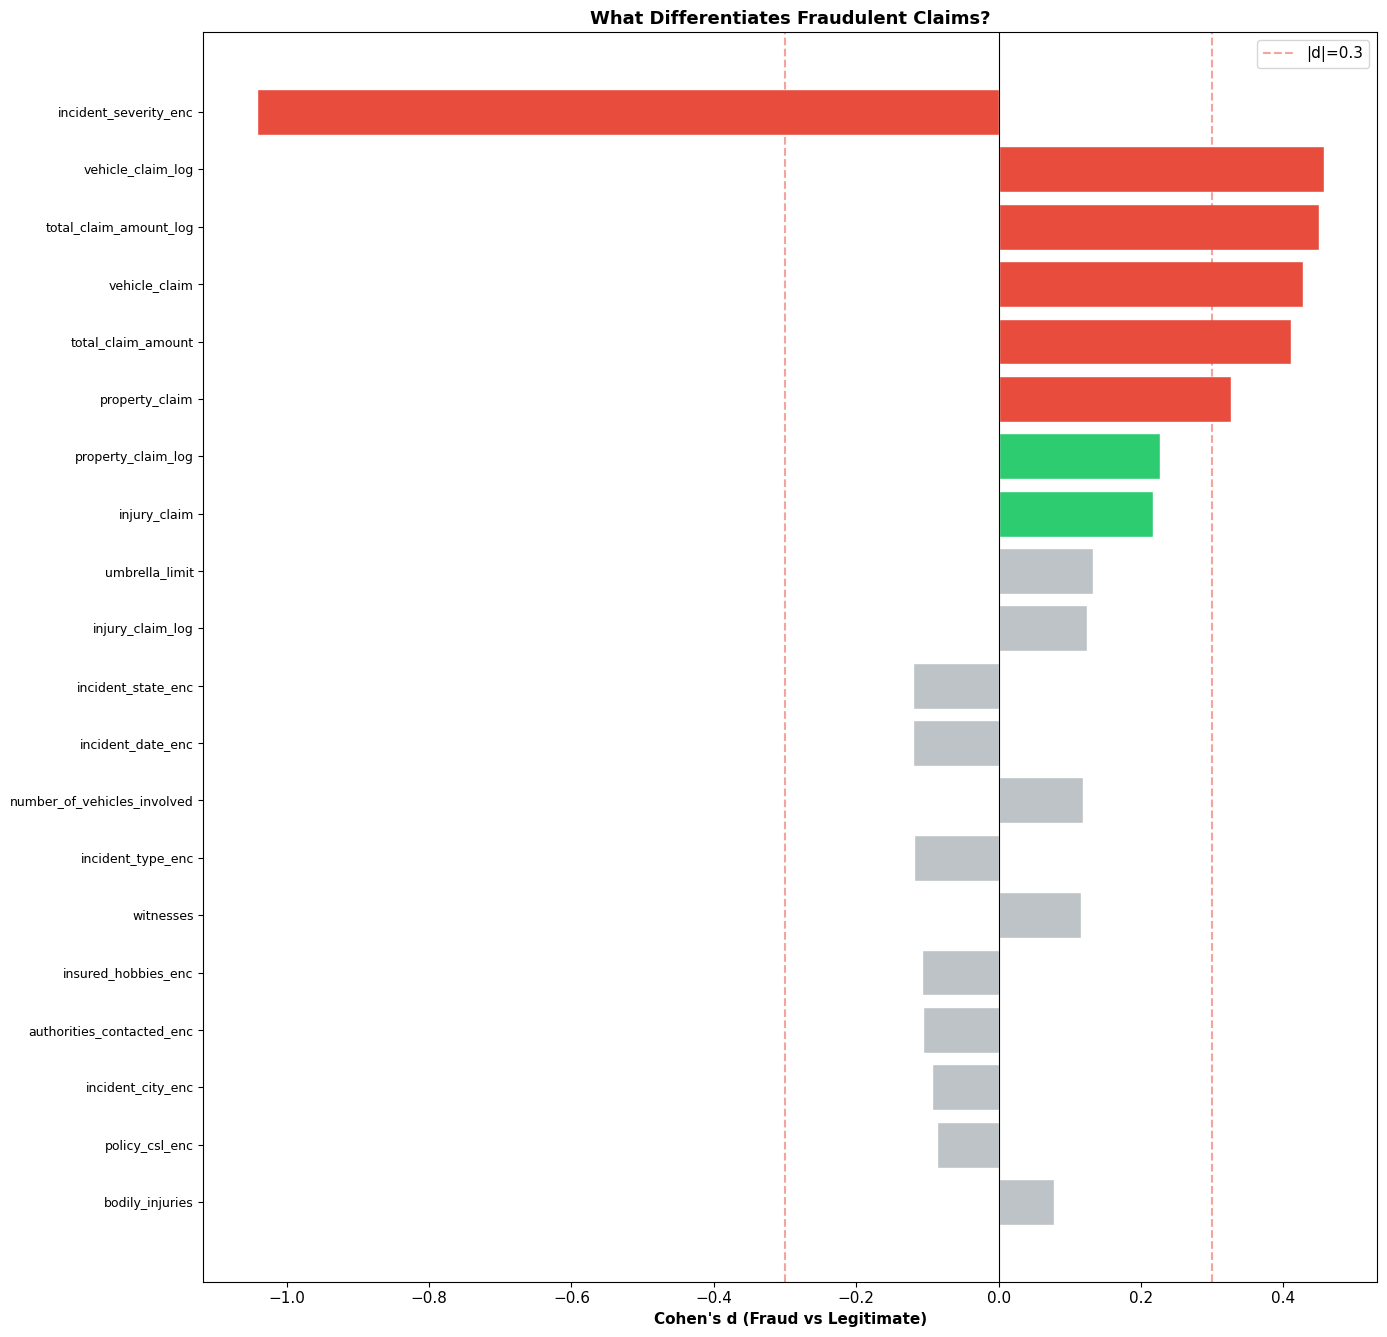

Top risk indicators:
  incident_severity_enc                d=-1.042  (LOWER in fraud)
  vehicle_claim_log                    d=+0.457  (HIGHER in fraud)
  total_claim_amount_log               d=+0.451  (HIGHER in fraud)
  vehicle_claim                        d=+0.427  (HIGHER in fraud)
  total_claim_amount                   d=+0.411  (HIGHER in fraud)
  property_claim                       d=+0.326  (HIGHER in fraud)
  property_claim_log                   d=+0.227  (HIGHER in fraud)
  injury_claim                         d=+0.216  (HIGHER in fraud)


In [12]:
# 4.1 Cohen's d effect sizes
cohens_d_results = {}
for i, col in enumerate(feature_cols):
    legit_vals = X[y == 0, i]
    fraud_vals = X[y == 1, i]
    pooled_std = np.sqrt((legit_vals.std()**2 + fraud_vals.std()**2) / 2)
    d = (fraud_vals.mean() - legit_vals.mean()) / pooled_std if pooled_std > 0 else 0
    cohens_d_results[col] = d

sorted_effects = sorted(cohens_d_results.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(14, max(8, len(feature_cols) * 0.3)))
features_sorted = [x[0] for x in sorted_effects[:20]]
effects_sorted = [x[1] for x in sorted_effects[:20]]
colors = [COLOR_FRAUD if abs(d) > 0.3 else COLOR_LEGIT if abs(d) > 0.15 else '#bdc3c7' for d in effects_sorted]

ax.barh(range(len(features_sorted)), effects_sorted, color=colors, edgecolor='white')
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted, fontsize=9)
ax.set_xlabel("Cohen's d (Fraud vs Legitimate)", fontweight='bold')
ax.set_title("What Differentiates Fraudulent Claims?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.3, color=COLOR_FRAUD, linestyle='--', alpha=0.5, label='|d|=0.3')
ax.axvline(x=-0.3, color=COLOR_FRAUD, linestyle='--', alpha=0.5)
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top risk indicators:")
for feat, d in sorted_effects[:8]:
    direction = "HIGHER in fraud" if d > 0 else "LOWER in fraud"
    print(f"  {feat:35s}  d={d:+.3f}  ({direction})")

---
## 5. Model Training & Comparison

Four models, 3-fold CV, OOF predictions. Same proven framework as the rest of the portfolio.

**Critical design choice:** In welfare fraud detection, **recall matters most** — missing a fraudulent claim costs more than investigating a legitimate one. However, post-Robodebt, we must also respect precision — flagging too many legitimate claimants for investigation causes real harm to vulnerable people.

In [13]:
# 5.1 Model definitions
n_fraud = y.sum()
n_legit = (1 - y).sum()
scale_ratio = n_legit / n_fraud

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42,
        n_jobs=-1, max_depth=10, min_samples_leaf=5
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, scale_pos_weight=scale_ratio,
        random_state=42, eval_metric='logloss',
        max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, max_depth=-1, learning_rate=0.05,
        n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
        reg_alpha=0.1, reg_lambda=1.0
    )
}

print(f"Class ratio: 1:{scale_ratio:.1f} | Samples: {len(X):,} | Features: {X.shape[1]}")

Class ratio: 1:3.0 | Samples: 1,000 | Features: 45


In [14]:
# 5.2 3-fold CV
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
results = {}
oof_preds = {}
oof_probs = {}

for model_name, model_template in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    oof_pred = np.zeros(len(y), dtype=int)
    oof_prob = np.zeros(len(y), dtype=float)
    start_time = time.time()
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        model = clone(model_template)
        model.fit(X[train_idx], y[train_idx])
        
        oof_pred[val_idx] = model.predict(X[val_idx])
        oof_prob[val_idx] = model.predict_proba(X[val_idx])[:, 1]
        
        f1_v = f1_score(y[val_idx], oof_pred[val_idx])
        pr_v = average_precision_score(y[val_idx], oof_prob[val_idx])
        roc_v = roc_auc_score(y[val_idx], oof_prob[val_idx])
        print(f"  Fold {fold+1}: F1={f1_v:.4f} | PR-AUC={pr_v:.4f} | ROC-AUC={roc_v:.4f}")
    
    elapsed = time.time() - start_time
    results[model_name] = {
        'accuracy': accuracy_score(y, oof_pred),
        'precision': precision_score(y, oof_pred, zero_division=0),
        'recall': recall_score(y, oof_pred, zero_division=0),
        'f1': f1_score(y, oof_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, oof_prob),
        'pr_auc': average_precision_score(y, oof_prob),
        'brier': brier_score_loss(y, oof_prob),
        'time': elapsed
    }
    oof_preds[model_name] = oof_pred
    oof_probs[model_name] = oof_prob
    
    r = results[model_name]
    print(f"  OOF: F1={r['f1']:.4f} | PR-AUC={r['pr_auc']:.4f} | ROC-AUC={r['roc_auc']:.4f}")


Training: Logistic Regression
  Fold 1: F1=0.5352 | PR-AUC=0.4755 | ROC-AUC=0.7682
  Fold 2: F1=0.5123 | PR-AUC=0.4135 | ROC-AUC=0.6901
  Fold 3: F1=0.4793 | PR-AUC=0.4381 | ROC-AUC=0.7030
  OOF: F1=0.5087 | PR-AUC=0.4308 | ROC-AUC=0.7169

Training: Random Forest
  Fold 1: F1=0.6013 | PR-AUC=0.5517 | ROC-AUC=0.8217
  Fold 2: F1=0.5767 | PR-AUC=0.4859 | ROC-AUC=0.7946
  Fold 3: F1=0.5366 | PR-AUC=0.5507 | ROC-AUC=0.8051
  OOF: F1=0.5708 | PR-AUC=0.5155 | ROC-AUC=0.8048

Training: XGBoost
  Fold 1: F1=0.6335 | PR-AUC=0.6408 | ROC-AUC=0.8576
  Fold 2: F1=0.6705 | PR-AUC=0.5228 | ROC-AUC=0.7951
  Fold 3: F1=0.7629 | PR-AUC=0.6167 | ROC-AUC=0.8750
  OOF: F1=0.6930 | PR-AUC=0.5800 | ROC-AUC=0.8404

Training: LightGBM
  Fold 1: F1=0.7294 | PR-AUC=0.6292 | ROC-AUC=0.8506
  Fold 2: F1=0.6851 | PR-AUC=0.5434 | ROC-AUC=0.8009
  Fold 3: F1=0.7330 | PR-AUC=0.6529 | ROC-AUC=0.8792
  OOF: F1=0.7159 | PR-AUC=0.5991 | ROC-AUC=0.8412


In [15]:
# 5.3 Results table
print("\n" + "=" * 95)
print("MODEL COMPARISON")
print("=" * 95)
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'ROC':>7} {'PR-AUC':>7} {'Brier':>7} {'Time':>6}")
print("-" * 95)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} {r['roc_auc']:>7.4f} {r['pr_auc']:>7.4f} {r['brier']:>7.4f} {r['time']:>5.1f}s")

best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest by PR-AUC: {best_model[0]} ({best_model[1]['pr_auc']:.4f})")


MODEL COMPARISON
Model                      Acc    Prec  Recall      F1     ROC  PR-AUC   Brier   Time
-----------------------------------------------------------------------------------------------
Logistic Regression     0.6890  0.4171  0.6518  0.5087  0.7169  0.4308  0.2112   0.1s
Random Forest           0.7940  0.5880  0.5547  0.5708  0.8048  0.5155  0.1511   1.0s
XGBoost                 0.8370  0.6479  0.7449  0.6930  0.8404  0.5800  0.1290   0.7s
LightGBM                0.8460  0.6576  0.7854  0.7159  0.8412  0.5991  0.1217   0.6s

Best by PR-AUC: LightGBM (0.5991)


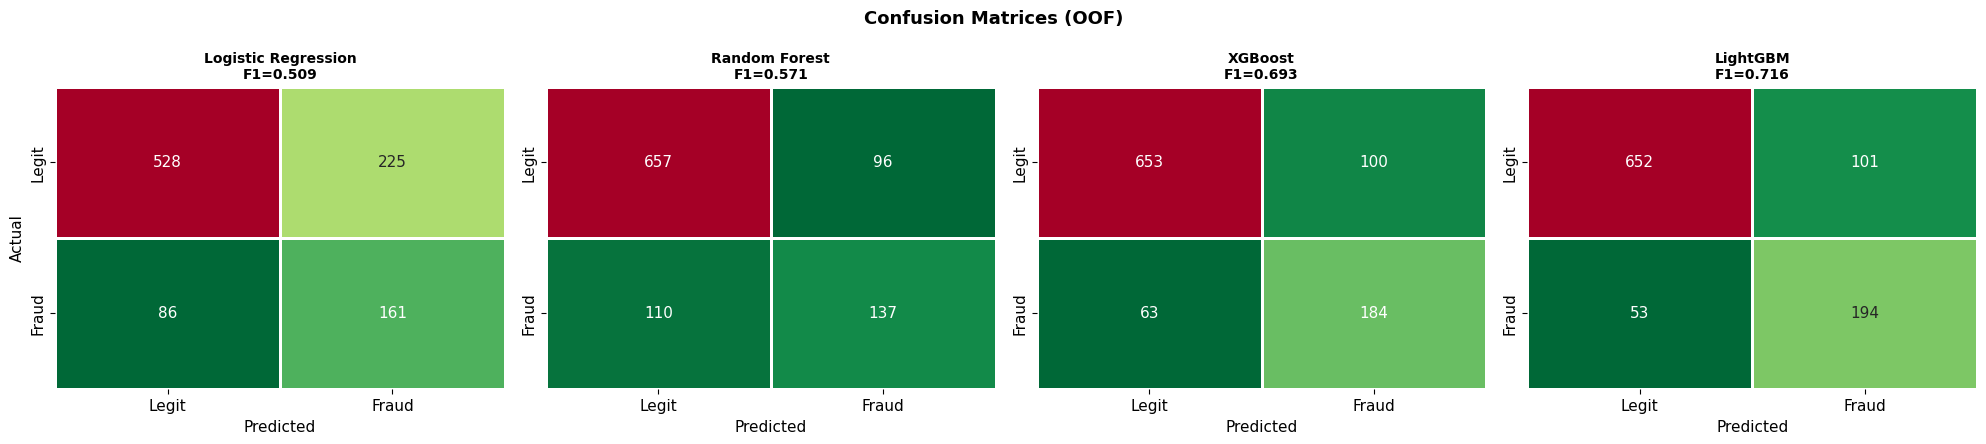

In [16]:
# 5.4 Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, (name, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
                cbar=False, linewidths=1, linecolor='white')
    axes[idx].set_title(f'{name}\nF1={results[name]["f1"]:.3f}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices (OOF)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

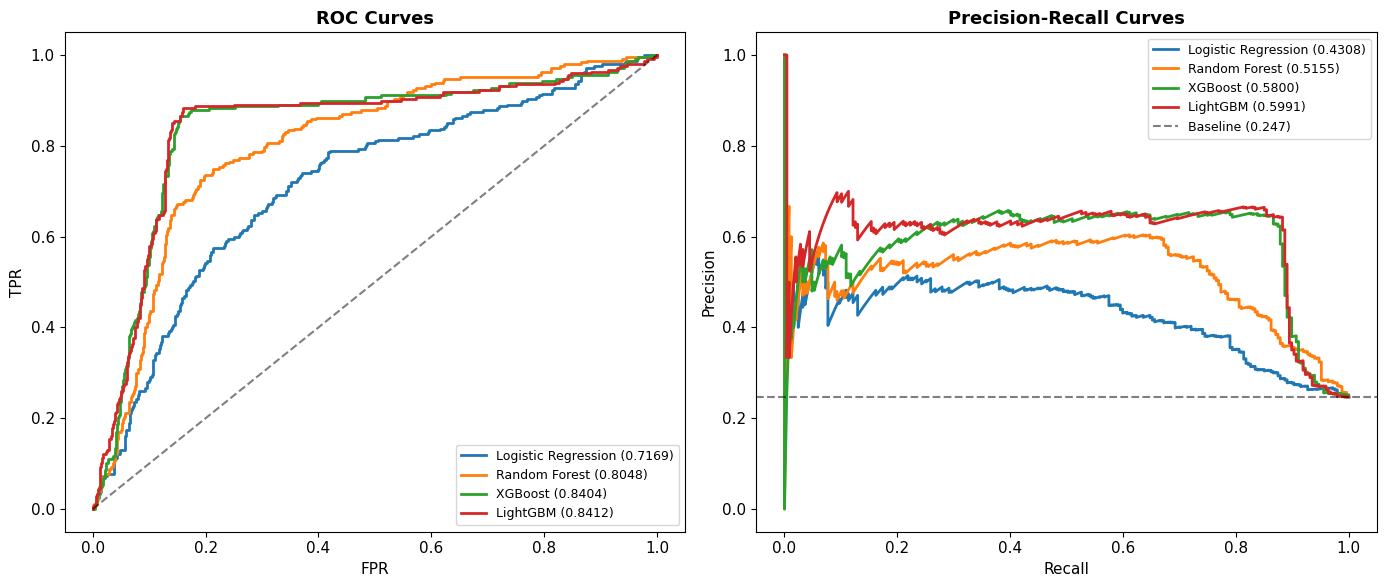

In [17]:
# 5.5 ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({results[name]['roc_auc']:.4f})", linewidth=2)
    prec, rec, _ = precision_recall_curve(y, prob)
    axes[1].plot(rec, prec, label=f"{name} ({results[name]['pr_auc']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=9)

axes[1].axhline(y=y.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline ({y.mean():.3f})')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

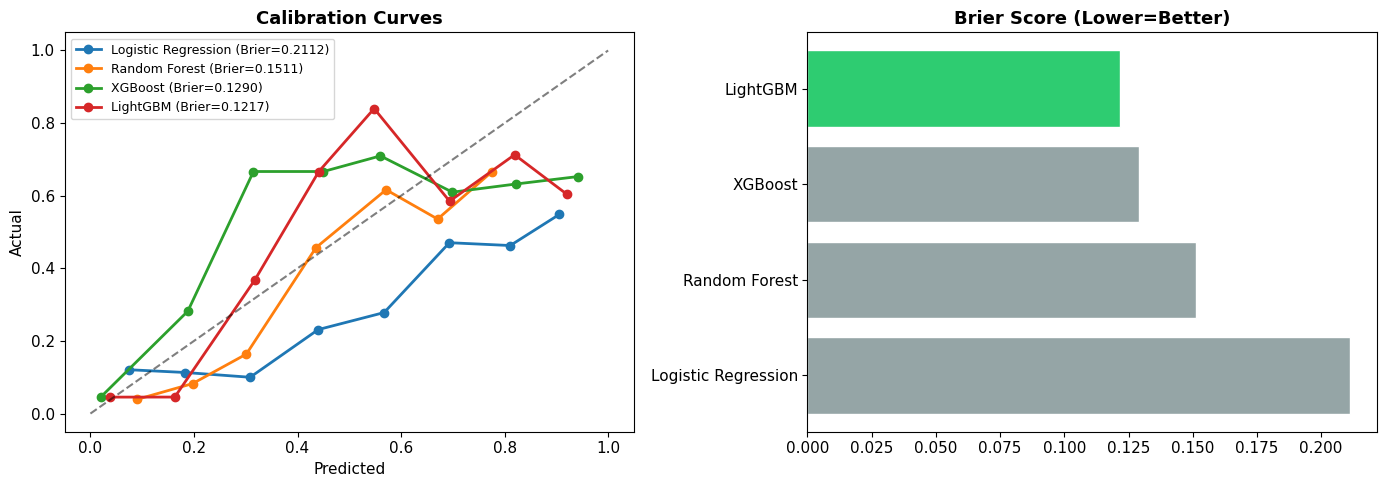

In [18]:
# 5.6 Calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, prob in oof_probs.items():
    pt, pp = calibration_curve(y, prob, n_bins=8, strategy='uniform')
    axes[0].plot(pp, pt, marker='o', label=f"{name} (Brier={results[name]['brier']:.4f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('Calibration Curves', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].legend(fontsize=9)

brier = [results[n]['brier'] for n in results]
colors_b = [COLOR_LEGIT if b == min(brier) else '#95a5a6' for b in brier]
axes[1].barh(list(results.keys()), brier, color=colors_b, edgecolor='white')
axes[1].set_title('Brier Score (Lower=Better)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

Post-Robodebt, the cost of false positives in welfare compliance is understood differently:

| Action | Cost | Who bears it |
|--------|------|-------------|
| **False Positive** (investigating a legitimate claimant) | Stress, anxiety, financial hardship for vulnerable person + staff time | The claimant — often the most vulnerable |
| **False Negative** (missing fraud) | Continued overpayment, integrity risk | The taxpayer |
| **True Positive** (catching real fraud) | Recovery of overpayment, deterrent effect | Net positive |

The Robodebt lesson: **the cost of wrongly accusing a vulnerable person is not just financial — it's human.**

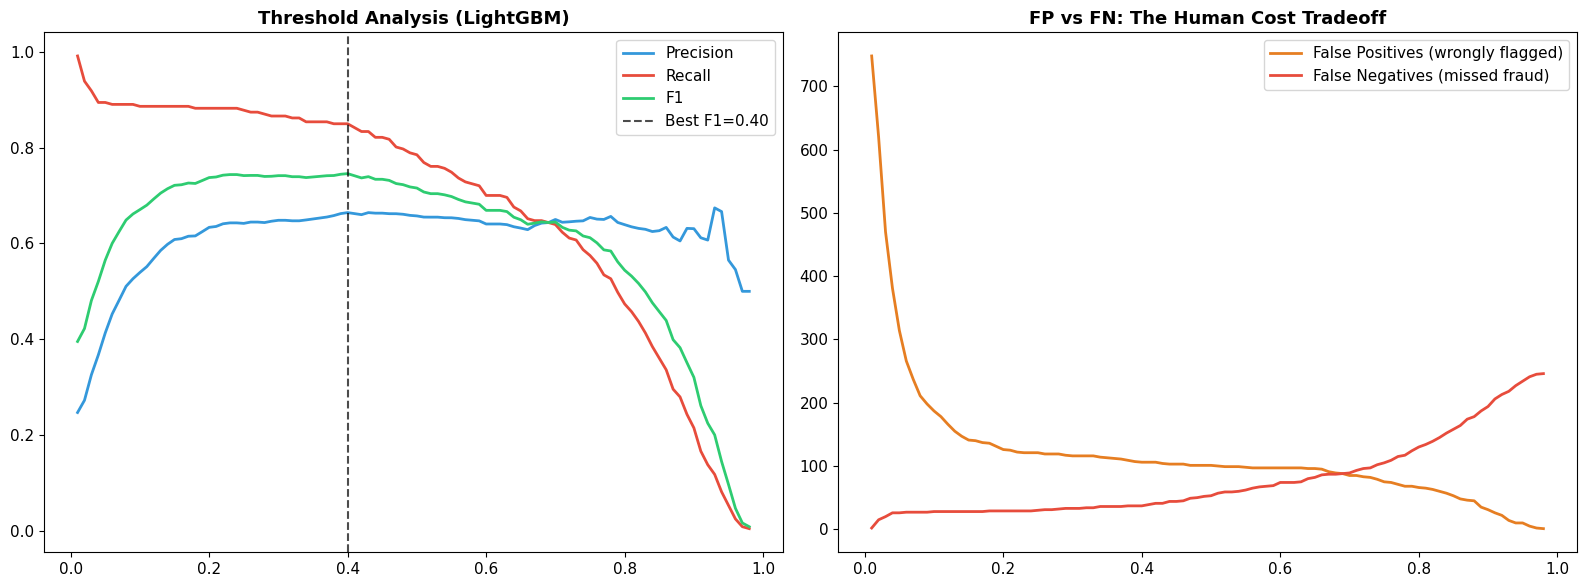

In [19]:
# 6.1 Threshold analysis
best_name = best_model[0]
best_prob = oof_probs[best_name]
thresholds = np.arange(0.01, 0.99, 0.01)
threshold_results = []

for thresh in thresholds:
    pred_t = (best_prob >= thresh).astype(int)
    tp = ((pred_t == 1) & (y == 1)).sum()
    fp = ((pred_t == 1) & (y == 0)).sum()
    fn = ((pred_t == 0) & (y == 1)).sum()
    tn = ((pred_t == 0) & (y == 0)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_v = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    threshold_results.append({'threshold': thresh, 'precision': prec, 'recall': rec, 'f1': f1_v,
                              'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})

thr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_FRAUD, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_LEGIT, label='F1', linewidth=2)
best_f1_idx = thr_df['f1'].idxmax()
best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', alpha=0.7, label=f'Best F1={best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold Analysis ({best_name})', fontweight='bold')
axes[0].legend()

axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='False Positives (wrongly flagged)', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_FRAUD, label='False Negatives (missed fraud)', linewidth=2)
axes[1].set_title('FP vs FN: The Human Cost Tradeoff', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

In [20]:
# 6.2 Scenario analysis — welfare compliance contexts
COST_FP_WELFARE = 5000    # Wrongly flagged: distress to vulnerable person, staff time, complaints
COST_FN = 15000           # Missed fraud: continued overpayment
COST_TP = 500             # Correct flag: efficient review

scenarios = {
    'Post-Robodebt Conservative (high prec)': 0.70,
    'Balanced (Best F1)': best_f1_thresh,
    'Standard Compliance': 0.40,
    'Aggressive (pre-Robodebt era)': 0.20,
}

print("=" * 95)
print("WELFARE COMPLIANCE SCENARIO ANALYSIS")
print(f"FP cost (wrongly flagging legitimate claimant): ${COST_FP_WELFARE:,}")
print(f"FN cost (missing fraud): ${COST_FN:,}")
print("=" * 95)
print(f"\n{'Scenario':<45} {'Thresh':>6} {'Recall':>7} {'Prec':>7} {'FP':>5} {'FN':>5} {'Cost':>10}")
print("-" * 95)

for name, thresh in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold'] - thresh).abs().argsort()[:1]].iloc[0]
    total = row['fn'] * COST_FN + row['fp'] * COST_FP_WELFARE + row['tp'] * COST_TP
    print(f"{name:<45} {thresh:>6.2f} {row['recall']:>7.4f} {row['precision']:>7.4f} "
          f"{int(row['fp']):>5} {int(row['fn']):>5} ${total:>9,.0f}")

print(f"\nPost-Robodebt lesson: The 'aggressive' threshold catches more fraud but wrongly")
print(f"flags many legitimate claimants. The conservative threshold protects vulnerable people")
print(f"while still identifying the highest-risk claims for human review.")

WELFARE COMPLIANCE SCENARIO ANALYSIS
FP cost (wrongly flagging legitimate claimant): $5,000
FN cost (missing fraud): $15,000

Scenario                                      Thresh  Recall    Prec    FP    FN       Cost
-----------------------------------------------------------------------------------------------
Post-Robodebt Conservative (high prec)          0.70  0.6397  0.6502    85    89 $1,839,000
Balanced (Best F1)                              0.40  0.8502  0.6646   106    37 $1,190,000
Standard Compliance                             0.40  0.8502  0.6646   106    37 $1,190,000
Aggressive (pre-Robodebt era)                   0.20  0.8826  0.6337   126    29 $1,174,000

Post-Robodebt lesson: The 'aggressive' threshold catches more fraud but wrongly
flags many legitimate claimants. The conservative threshold protects vulnerable people
while still identifying the highest-risk claims for human review.


---
## 7. Model Interpretability & Fairness Safeguards

This section is arguably the most important in the entire notebook. Post-Robodebt, any ML system in welfare compliance must demonstrate:

1. **Transparency** — what factors drive the risk score?
2. **Fairness** — does the model disproportionately flag certain demographic groups?
3. **Accountability** — who is responsible when the model is wrong?
4. **Natural justice** — does the claimant have a right to respond before adverse action?

The APS Code of Conduct (Public Service Act 1999 s.13) requires public servants to act with care and diligence. Deploying an unexplainable ML system that harms vulnerable people violates this obligation.

In [21]:
# 7.1 Feature importance
importances = {}
lr_f = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_f.fit(X, y); importances['Logistic Regression'] = np.abs(lr_f.coef_[0])

rf_f = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=10)
rf_f.fit(X, y); importances['Random Forest'] = rf_f.feature_importances_

xgb_f = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_ratio, random_state=42, 
                            eval_metric='logloss', max_depth=6, verbosity=0)
xgb_f.fit(X, y); importances['XGBoost'] = xgb_f.feature_importances_

lgb_f = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, 
                             max_depth=-1, learning_rate=0.05, verbose=-1, num_leaves=31,
                             min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0)
lgb_f.fit(X, y); importances['LightGBM'] = lgb_f.feature_importances_

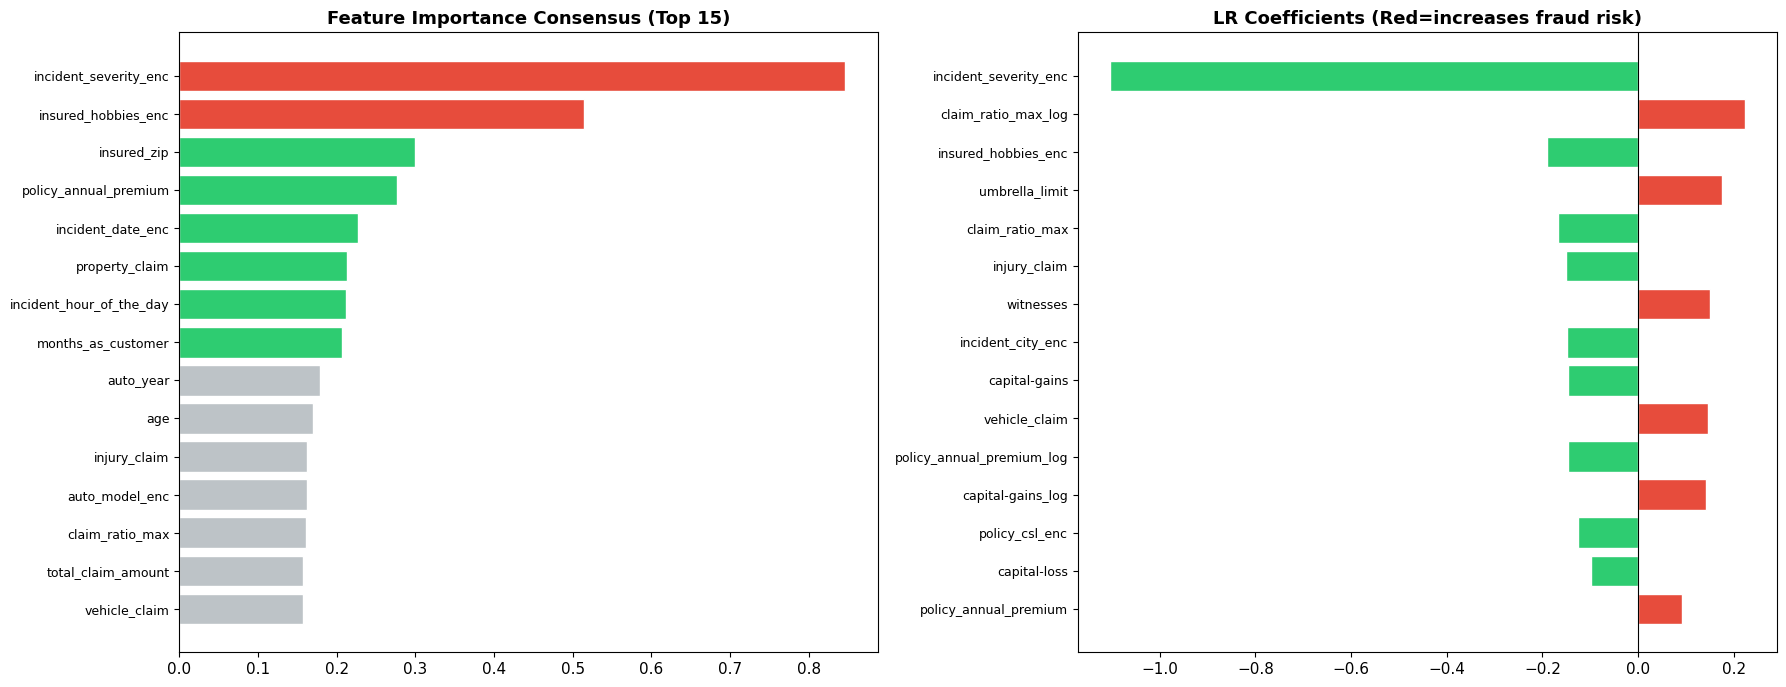

Top 5 fraud indicators:
  [1] incident_severity_enc (importance: 0.846)
  [2] insured_hobbies_enc (importance: 0.514)
  [3] insured_zip (importance: 0.299)
  [4] policy_annual_premium (importance: 0.277)
  [5] incident_date_enc (importance: 0.228)


In [22]:
# 7.2 Consensus importance
norm_imp = {}
for name, imp in importances.items():
    mx = imp.max()
    norm_imp[name] = imp / mx if mx > 0 else imp

avg_imp = np.mean([norm_imp[m] for m in norm_imp], axis=0)
sorted_idx = np.argsort(avg_imp)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_names = [feature_cols[i] for i in sorted_idx]
top_vals = avg_imp[sorted_idx]
colors_i = [COLOR_FRAUD if v > 0.4 else COLOR_LEGIT if v > 0.2 else '#bdc3c7' for v in top_vals]

axes[0].barh(range(len(top_names)), top_vals, color=colors_i, edgecolor='white')
axes[0].set_yticks(range(len(top_names))); axes[0].set_yticklabels(top_names, fontsize=9)
axes[0].set_title('Feature Importance Consensus (Top 15)', fontweight='bold')
axes[0].invert_yaxis()

lr_coefs = lr_f.coef_[0]
lr_idx = np.argsort(np.abs(lr_coefs))[::-1][:15]
lr_names = [feature_cols[i] for i in lr_idx]
lr_vals = lr_coefs[lr_idx]
lr_colors = [COLOR_FRAUD if c > 0 else COLOR_LEGIT for c in lr_vals]

axes[1].barh(range(len(lr_names)), lr_vals, color=lr_colors, edgecolor='white')
axes[1].set_yticks(range(len(lr_names))); axes[1].set_yticklabels(lr_names, fontsize=9)
axes[1].set_title('LR Coefficients (Red=increases fraud risk)', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 fraud indicators:")
for i, feat in enumerate(top_names[:5]):
    print(f"  [{i+1}] {feat} (importance: {top_vals[i]:.3f})")

In [23]:
# 7.3 Fairness audit — check for demographic disparities
print("=" * 70)
print("FAIRNESS AUDIT — Demographic Disparity Check")
print("=" * 70)
print("\nChecking whether the model disproportionately flags certain groups...")

# Check key demographic columns
demo_cols = [c for c in df.columns if any(kw in c.lower() for kw in 
             ['gender', 'sex', 'age', 'education', 'occupation', 'race', 'state'])]

best_prob_series = pd.Series(oof_probs[best_name], index=df.index)

for col in demo_cols[:4]:
    if col in df.columns and df[col].nunique() <= 15:
        print(f"\n  {col}:")
        for val in df[col].unique():
            mask = df[col] == val
            if mask.sum() < 10:
                continue
            actual = (df.loc[mask, target_col] == minority_class).mean()
            predicted = best_prob_series[mask].mean()
            n = mask.sum()
            gap = predicted - actual
            flag = " ⚠️ REVIEW" if abs(gap) > 0.05 else ""
            print(f"    {str(val):25s} n={n:>4} | Actual fraud: {actual:.3f} | "
                  f"Model score: {predicted:.3f} | Gap: {gap:+.3f}{flag}")

print(f"\n{'='*70}")
print("FAIRNESS NOTES:")
print("  • Small gaps (<0.05) between actual and predicted rates are acceptable")
print("  • Large gaps suggest the model may be introducing systematic bias")
print("  • Any demographic-based disparities must be reviewed by compliance officers")
print("  • The Racial Discrimination Act 1975 and Sex Discrimination Act 1984 apply")
print("  • Post-Robodebt: disproportionate impact on vulnerable groups is unacceptable")

FAIRNESS AUDIT — Demographic Disparity Check

Checking whether the model disproportionately flags certain groups...

  policy_state:
    OH                        n= 352 | Actual fraud: 0.259 | Model score: 0.301 | Gap: +0.042
    IN                        n= 310 | Actual fraud: 0.255 | Model score: 0.270 | Gap: +0.015
    IL                        n= 338 | Actual fraud: 0.228 | Model score: 0.290 | Gap: +0.062 ⚠️ REVIEW

  insured_sex:
    MALE                      n= 463 | Actual fraud: 0.261 | Model score: 0.302 | Gap: +0.040
    FEMALE                    n= 537 | Actual fraud: 0.235 | Model score: 0.276 | Gap: +0.041

  insured_education_level:
    MD                        n= 144 | Actual fraud: 0.264 | Model score: 0.312 | Gap: +0.048
    PhD                       n= 125 | Actual fraud: 0.264 | Model score: 0.293 | Gap: +0.029
    Associate                 n= 145 | Actual fraud: 0.234 | Model score: 0.291 | Gap: +0.056 ⚠️ REVIEW
    Masters                   n= 143 | Actual fraud

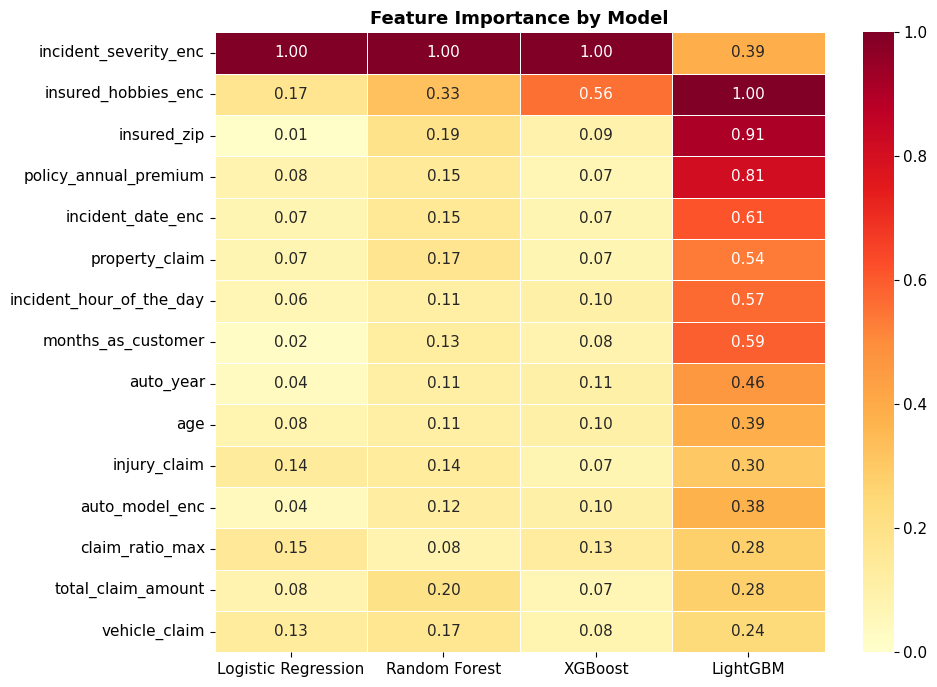

In [24]:
# 7.4 Heatmap
top_n = min(15, len(feature_cols))
top_idx_h = np.argsort(avg_imp)[::-1][:top_n]
hm_data = pd.DataFrame({n: [norm_imp[n][i] for i in top_idx_h] for n in norm_imp},
                         index=[feature_cols[i] for i in top_idx_h])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Feature Importance by Model', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Production Deployment Considerations

### Welfare Compliance Architecture (Post-Robodebt Design)

```
Payment Data + Third-Party Data Matching (ATO, banks, employers)
    │
    ▼
Risk Scoring Engine (batch, NOT real-time)
    │
    ├── LOW RISK (score < 0.3) ──► No action, routine monitoring
    │
    ├── MEDIUM RISK (0.3 ≤ score < 0.6) ──► Soft intervention
    │       └── Letter requesting updated information
    │       └── Claimant has 28 days to respond (natural justice)
    │
    └── HIGH RISK (score ≥ 0.6) ──► Case officer review
            ├── Manual assessment by trained compliance officer
            ├── Contact claimant directly (NOT automated letter)
            ├── Consider personal circumstances and vulnerability
            └── Decision documented with reasons (AAT-reviewable)
    │
    ▼
Review Rights: Internal review → AAT/ART → Federal Court
```

### Regulatory Framework

| Legislation | Relevance |
|-------------|-----------|
| **Social Security Act 1991** | Legal basis for all welfare decisions |
| **Social Security (Administration) Act 1999** | Decision-making procedures, review rights |
| **Privacy Act 1988** | Data matching rules, APPs |
| **Public Service Act 1999 s.13** | APS Code of Conduct — care and diligence |
| **Freedom of Information Act 1982** | Transparency of government decisions |
| **AI Ethics Framework** | Responsible AI in government |
| **Robodebt Royal Commission recommendations** | Mandatory human oversight, legal basis, natural justice |

### Non-Negotiable Safeguards (Post-Robodebt)

1. **Legal basis**: Every compliance action must have a specific legal basis under the Social Security Act. "The model said so" is not a legal basis.

2. **Human-in-the-loop**: No automated adverse decisions. Every case flagged by the model must be reviewed by a trained compliance officer who considers individual circumstances.

3. **Natural justice**: Claimants must be given the opportunity to respond before any adverse action. This means clear communication about what information is being questioned and why.

4. **Vulnerability assessment**: Before any compliance action, assess whether the claimant is in a vulnerable cohort (disability, mental health, Indigenous, CALD, homelessness). Apply additional protections.

5. **Audit trail**: Every model prediction, human decision, and outcome must be logged for AAT review and ministerial accountability.

6. **Regular fairness audits**: Quarterly analysis of compliance outcomes by demographic group. Any disproportionate impact triggers immediate review.

---
## 9. Key Takeaways

In [25]:
print("=" * 70)
print("BENEFITS & CLAIMS FRAUD DETECTION — KEY RESULTS")
print("=" * 70)

print(f"\n1. DATASET: {len(df):,} claims, {fraud_pct:.1f}% fraud rate")

print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:  {best_model[1]['pr_auc']:.4f}")
print(f"   ROC-AUC: {best_model[1]['roc_auc']:.4f}")
print(f"   F1:      {best_model[1]['f1']:.4f}")

print(f"\n3. MODEL COMPARISON (PR-AUC):")
for name in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    m = " ◄ BEST" if name == best_model[0] else ""
    print(f"   {name:<22} {results[name]['pr_auc']:.4f}{m}")

print(f"\n4. THRESHOLD ECONOMICS:")
print(f"   Best F1 threshold: {best_f1_thresh:.2f}")
print(f"   Post-Robodebt conservative (0.70): Protects vulnerable claimants")
print(f"   Balanced ({best_f1_thresh:.2f}): Standard compliance operations")

print(f"\n5. TOP RISK FACTORS:")
for i, feat in enumerate(top_names[:5]):
    print(f"   [{i+1}] {feat} ({top_vals[i]:.3f})")

print(f"\n6. CRITICAL LESSONS (POST-ROBODEBT):")
print(f"   • ML is a DECISION-SUPPORT tool, never an automated decision-maker")
print(f"   • Every compliance action needs a specific legal basis (Social Security Act)")
print(f"   • Natural justice: claimants must be heard before adverse action")
print(f"   • Vulnerability assessment before any compliance intervention")
print(f"   • Fairness audits are mandatory — disproportionate impact is unacceptable")
print(f"   • Full audit trail for AAT review and ministerial accountability")
print(f"   • The cost of wrongly accusing a vulnerable person is not just financial")

print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime)")
print(f"  [4] Predictive Maintenance (Defence & Infrastructure)")
print(f"  [5] Visa Risk Scoring (Immigration & Border Security)")
print(f"  [6] Benefits Fraud Detection (Welfare Compliance) ← This notebook")
print(f"{'='*70}")

BENEFITS & CLAIMS FRAUD DETECTION — KEY RESULTS

1. DATASET: 1,000 claims, 24.7% fraud rate

2. BEST MODEL: LightGBM
   PR-AUC:  0.5991
   ROC-AUC: 0.8412
   F1:      0.7159

3. MODEL COMPARISON (PR-AUC):
   LightGBM               0.5991 ◄ BEST
   XGBoost                0.5800
   Random Forest          0.5155
   Logistic Regression    0.4308

4. THRESHOLD ECONOMICS:
   Best F1 threshold: 0.40
   Post-Robodebt conservative (0.70): Protects vulnerable claimants
   Balanced (0.40): Standard compliance operations

5. TOP RISK FACTORS:
   [1] incident_severity_enc (0.846)
   [2] insured_hobbies_enc (0.514)
   [3] insured_zip (0.299)
   [4] policy_annual_premium (0.277)
   [5] incident_date_enc (0.228)

6. CRITICAL LESSONS (POST-ROBODEBT):
   • ML is a DECISION-SUPPORT tool, never an automated decision-maker
   • Every compliance action needs a specific legal basis (Social Security Act)
   • Natural justice: claimants must be heard before adverse action
   • Vulnerability assessment before a